# BANANA

### IMPORT 

In [ ]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### PARAMS

In [2]:
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Keep: Captures the short-term microstructure beta
Z_WINDOW = 100              # Keep: Fast rolling mean to fade bid/ask bounces

ENTRY_Z = 1.50              # TWEAKED: Raised from 1.25
EXIT_Z = -0.25              # Keep: Captures momentum past the mean
AR_LIMIT = 0.985            # TWEAKED: Tightened from 0.995
DANGER_THRESHOLD = 0.95     # TWEAKED: Raised from 0.90

### DATA

In [3]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/gbpusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/gbpusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eurusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 24548 rows
                                   Asset_A    Bid_A    Ask_A   Asset_B  \
timestamp                                                                
2024-01-02 10:10:17.953000+00:00  1.271135  1.27111  1.27116  1.100680   
2024-01-02 10:13:59.158000+00:00  1.270445  1.27039  1.27050  1.100105   
2024-01-02 10:18:30.376000+00:00  1.270885  1.27084  1.27093  1.100045   

                                    Bid_B    Ask_B     Log_A     Log_B  \
timestamp                                                                
2024-01-02 10:10:17.953000+00:00  1.10067  1.10069  0.239910  0.095928   
2024-01-02 10:13:59.158000+00:00  1.10009  1.10012  0.239367  0.095406   
2024-01-02 10:18:30.376000+00:00  1.10004  1.10005  0.239714  0.095351   

                                  Return_A  Return_B  HalfSpread_A_bps  \
timestamp                                                                
2024-01-02 10:10:17.953000+00:00 -0.000283 -0.000386          0.196675   
2024-01-02 10:13:59

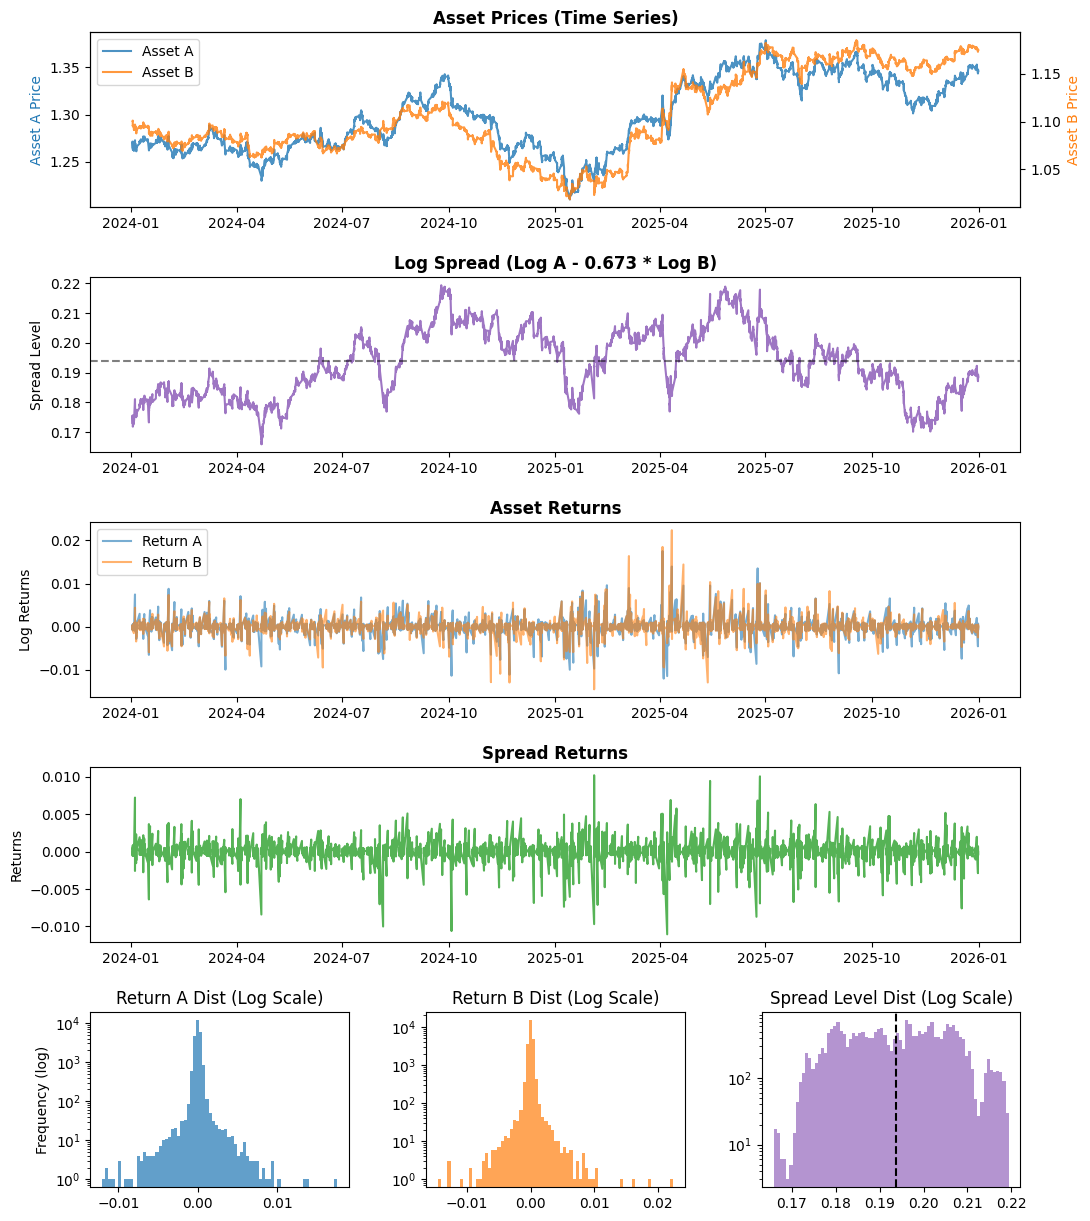

In [ ]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24)) # Build all hours first
df_raw = builder.build(files)

### DESCRIPTIVE 

In [ ]:
eda = DESCRIPTIVE(df_raw, name_a="AUD", name_b="NZD")
eda.generate_full_eda()

### SPREAD (AGAIN)

In [ ]:
df_final = df_raw[(df_raw.index.hour >= 0) & (df_raw.index.hour < 8)]

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.1324 | half-life=607.6 | β=0.6733

Rolling (2000-bar, step 200, n=113):
  p<0.05: 2.7% | p<0.10: 8.8%
  half-life: 104.7 (IQR 67–188)
  β: 0.9406 ±0.3265 [0.2536, 2.0145]


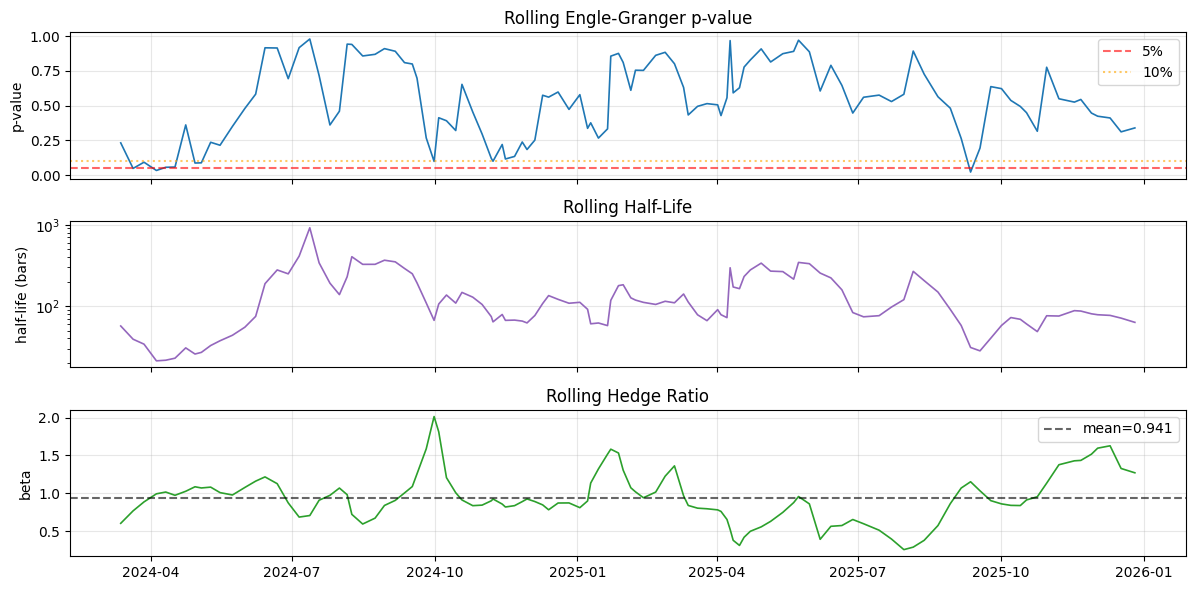

In [5]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [6]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [7]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 1.1589 | AR: 0.9424
[2024-02-27] Beta: 0.8088 | AR: 0.9613
[2024-03-12] Beta: 1.4130 | AR: 0.9442
[2024-03-26] Beta: 1.2822 | AR: 0.9518
[2024-04-09] Beta: 0.7108 | AR: 0.9425
[2024-04-23] Beta: 1.0235 | AR: 0.9808
[2024-05-07] Beta: 0.7979 | AR: 0.9752
[2024-05-21] Beta: 1.4357 | AR: 0.9795
[2024-06-04] Beta: 0.8624 | AR: 0.9905
[2024-06-18] Beta: 0.6762 | AR: 0.9891
[2024-07-02] Beta: 0.5299 | AR: 0.9824
[2024-07-16] Beta: 1.6575 | AR: 0.9731
[2024-07-30] Beta: 0.9865 | AR: 0.9701
[2024-08-13] Beta: 0.7771 | AR: 0.9765
[2024-08-27] Beta: 1.5040 | AR: 0.9805
[2024-09-10] Beta: 0.9593 | AR: 0.9872
[2024-09-24] Beta: 0.7406 | AR: 0.9819
[2024-10-08] Beta: 1.4369 | AR: 0.9860
[2024-10-22] Beta: 0.4964 | AR: 0.9846
[2024-11-05] Beta: -0.0784 | AR: 0.9742
[2024-11-19] Beta: 0.9051 | AR: 0.9838
[2024-12-03] Beta: 0.7136 | AR: 0.9846
[2024-12-17] Beta: 0.8954 | AR: 0.9864
[2025-01-02] Beta: 0.8595 | AR: 0.985

In [8]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | 2680.40      | 2582.60      | 1738.26      |
Annual Return (bps)            | 1381.31      | 1330.91      | 895.79       |
Annual Volatility (bps)        | 560.63       | 519.27       | 501.30       |
Max Drawdown (bps)             | -309.64      | -255.21      | -257.50      |
Sharpe Ratio                   | 2.46         | 2.56         | 1.79         |
Sortino Ratio                  | 2.84         | 2.85         | 1.90         |
Calmar Ratio                   | 4.46         | 5.22         | 3.48         |
Gross Profit (bps)             | 26587.07     | 22592.94     | 21377.39     |
Gross Loss (bps)               | 23906.67     | 20010.33     | 19639.13     |
Profit Factor                  | 1.11 

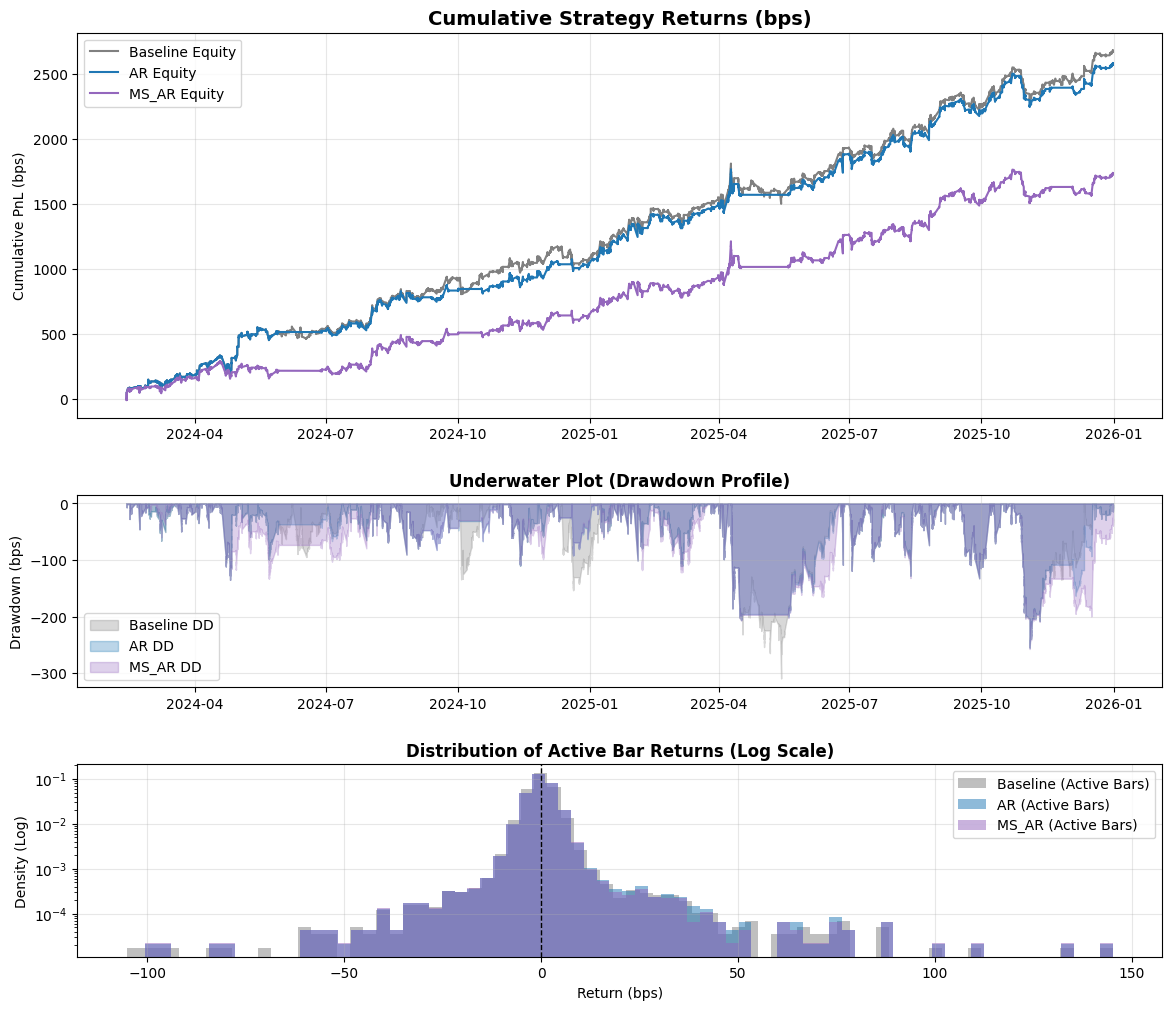

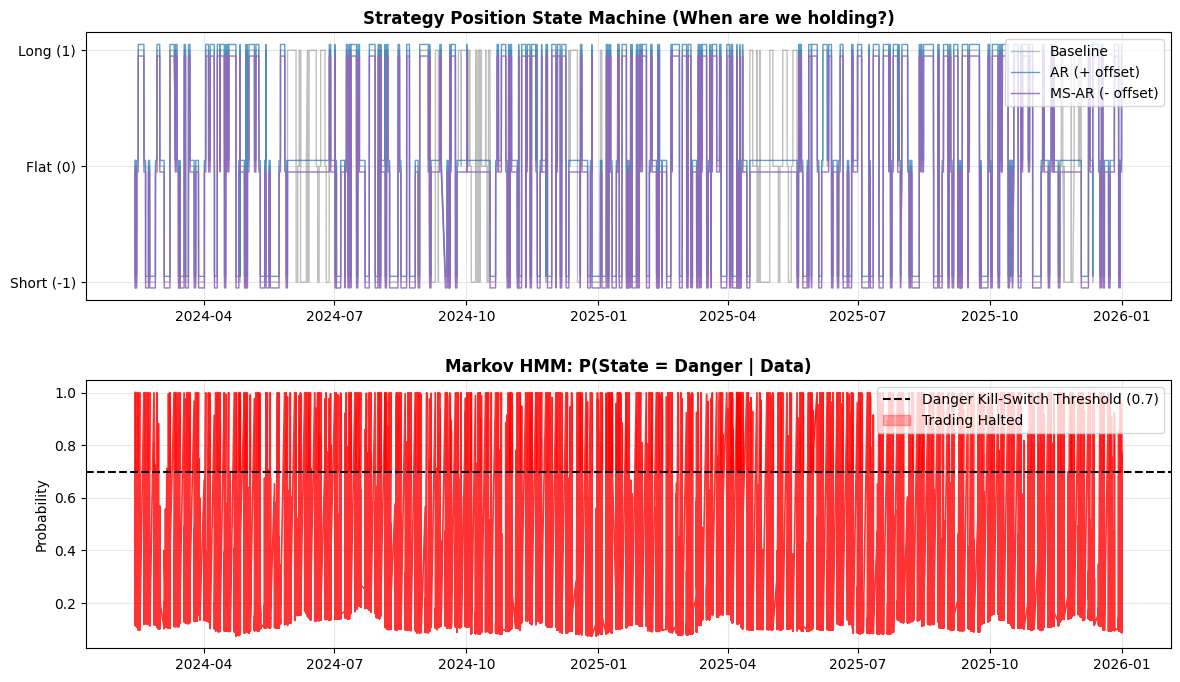

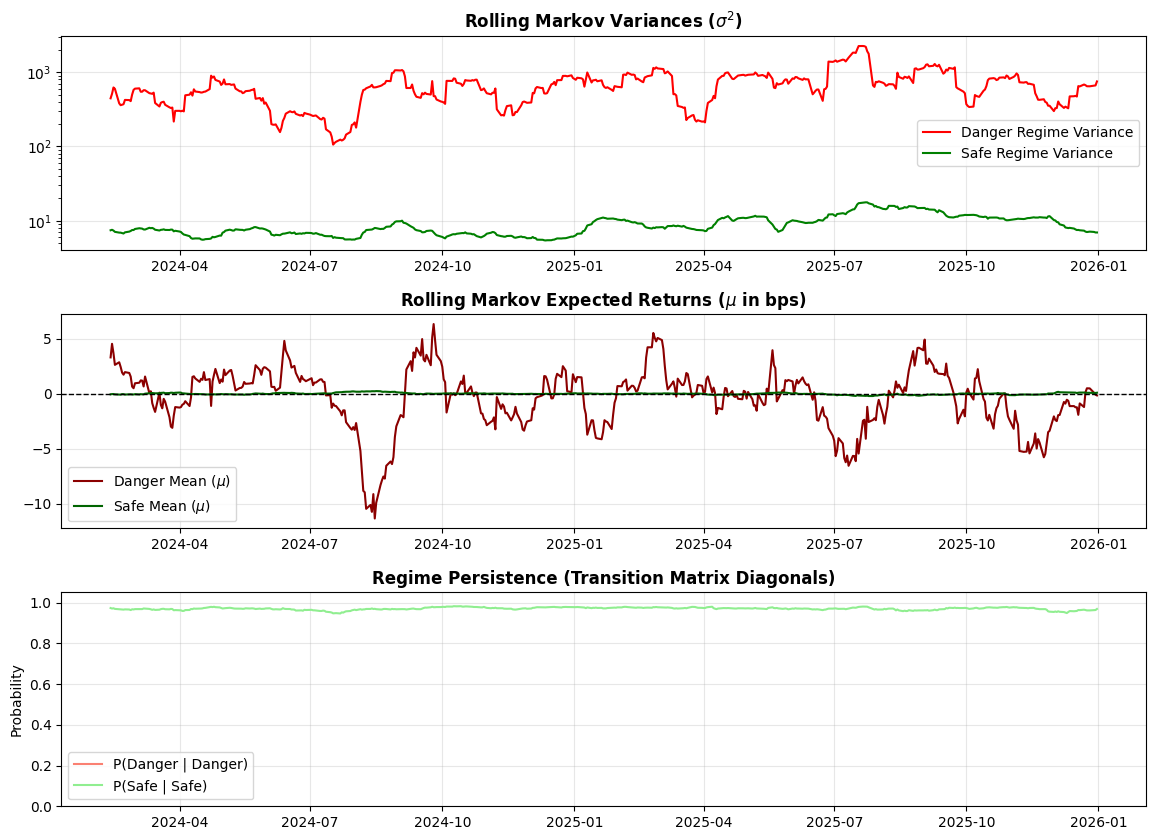

In [9]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()